# Model response variability

This notebook visualizes the spiking retinal model's response variability (Supplementary Figure 1). We hardcoded the noise sources to match the noise variability of the photoreceptors and the ganglion neurons in the retina. The model's response variability can be adjusted by changing the ```photo_noise``` and ```ganglion_noise``` variables in the ```RetinalParameters``` class that gets passed into the ```RetinaModel``` class. These variables can also be adjusted when training the model using the training script (```scripts/model/train.py```).

In [3]:
import os

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from retina import analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
root = os.path.expanduser("~/PycharmProjects/RetinalModel")

In [5]:
all_spike_stats = analysis.AllDatasetSpikeStats(root)

In [6]:
def plot_fano_factors(fanos, ax):
    list_data = []
    for v in fanos:
        list_data.append({"data": "exp", "y": v.item()})
    data_df = pd.DataFrame(list_data)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.xaxis.set_tick_params(width=3, labelsize=16, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=16, pad=8)
    ax.set_xlabel("Fano Factor", fontsize=20, labelpad=10)
    
    sns.histplot(data_df, x="y", stat="probability", bins=[0, 0.25, 0.5, 0.75, 1, 1.25], ax=ax)

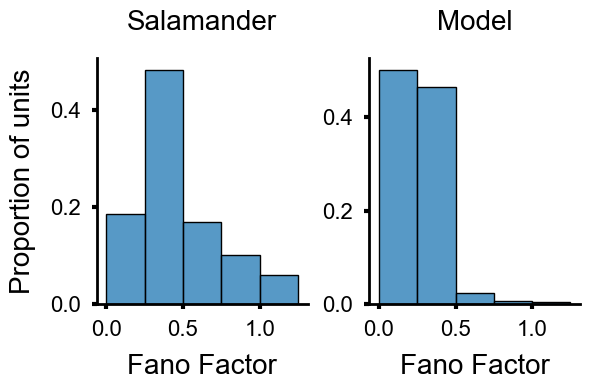

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(6, 4))
plot_fano_factors(all_spike_stats.sal_img_stats.exp_stats.fano, axs[0])
plot_fano_factors(all_spike_stats.sal_img_stats.pred_model_stats.fano, axs[1])
axs[0].set_ylabel("Proportion of units", fontsize=20, labelpad=10)
axs[1].set_ylabel("")
axs[0].set_title("Salamander", fontsize=20, pad=20)
axs[1].set_title("Model", fontsize=20, pad=20)
fig.tight_layout()
plt.savefig(f"{root}/figures/supp/fano_factors.svg", format="svg", transparent=False, bbox_inches="tight")

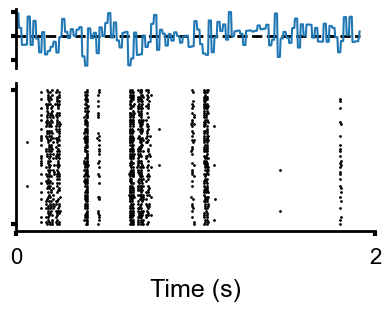

In [8]:
def plot_spike_precision(precision_query, intesity_ax, raster_ax):
    # Intensity plot
    intesity_ax.plot([0, len(precision_query.flicker_clip)], [0, 0], "--", c="black", linewidth=2)
    intesity_ax.plot(precision_query.flicker_clip)
    intesity_ax.spines["top"].set_visible(False)
    intesity_ax.spines["right"].set_visible(False)
    intesity_ax.spines["bottom"].set_visible(False)
    intesity_ax.spines["left"].set_linewidth(2)
    
    intesity_ax.yaxis.set_tick_params(width=3, labelsize=16, pad=8)
    intesity_ax.set_yticks([-2, 0, 2])
    intesity_ax.set_yticklabels(["", "", ""])
    intesity_ax.set_xlim([0, 500])
    intesity_ax.set_xticks([])
    intesity_ax.set_xticklabels([])
    intesity_ax.set_xlabel("")
    
    # Raster plot
    raster_x, raster_y = precision_query.get_spike_coo(84)
    raster_ax.scatter(raster_x, raster_y+1, s=1, c="black")
    raster_ax.spines["top"].set_visible(False)
    raster_ax.spines["right"].set_visible(False)
    raster_ax.spines["bottom"].set_linewidth(2)
    raster_ax.spines["left"].set_linewidth(2)
    raster_ax.xaxis.set_tick_params(width=3, labelsize=16, pad=8)
    raster_ax.yaxis.set_tick_params(width=3, labelsize=16, pad=8)
    raster_ax.set_yticks([1, 60])
    raster_ax.set_yticklabels(["", ""])
    raster_ax.set_xticks([0, 500])
    raster_ax.set_xticklabels([0, 2])
    raster_ax.set_xlabel("Time (s)", fontsize=18, labelpad=8)
    raster_ax.set_xlim([0, 500])


precision_query = analysis.PrecisionQuery(root, duration_ms=2000, n_trials=60, lum=1)


fig = plt.figure(constrained_layout=True, figsize=(3.8, 3))
spec = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[0.4, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
raster_ax = fig.add_subplot(spec[1]) 

plot_spike_precision(precision_query, intesity_ax, raster_ax)
plt.savefig(f"{root}/figures/supp/spike_precision.svg", format="svg", transparent=False, bbox_inches="tight")